# Análisis exploratorio de datos para el Stellar Classification Dataset - SDSS17

## Descripción del dataset en Kaggle
### Context
In astronomy, stellar classification is the classification of stars based on their spectral characteristics. The classification scheme of galaxies, quasars, and stars is one of the most fundamental in astronomy. The early cataloguing of stars and their distribution in the sky has led to the understanding that they make up our own galaxy and, following the distinction that Andromeda was a separate galaxy to our own, numerous galaxies began to be surveyed as more powerful telescopes were built. This datasat aims to classificate stars, galaxies, and quasars based on their spectral characteristics.

### Content
The data consists of 100,000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

1. obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
2. alpha = Right Ascension angle (at J2000 epoch)
3. delta = Declination angle (at J2000 epoch)
4. u = Ultraviolet filter in the photometric system
5. g = Green filter in the photometric system
6. r = Red filter in the photometric system
7. i = Near Infrared filter in the photometric system
8. z = Infrared filter in the photometric system
9. run_ID = Run Number used to identify the specific scan
10. rerun_ID = Rerun Number to specify how the image was processed
11. cam_col = Camera column to identify the scanline within the run
12. field_ID = Field number to identify each field
13. spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
14. class = object class (galaxy, star or quasar object)
15. redshift = redshift value based on the increase in wavelength
16. plate = plate ID, identifies each plate in SDSS
17. MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
18. fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

## Análisis a priori
Observando la descripción de cada uno de los features, se puede empezar a hacer una interpretación del tipo de variable y si tendrá influencia sobre la columna target.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/star_classification.csv')

print("Primeras 5 filas del dataset:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

Primeras 5 filas del dataset:
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354 

In [3]:
print("\nTamaño del dataset:")
print(df.shape)

print("\nEstadísticas descriptivas del dataset:")
print(df.describe())


Tamaño del dataset:
(100000, 18)

Estadísticas descriptivas del dataset:
             obj_ID          alpha          delta              u  \
count  1.000000e+05  100000.000000  100000.000000  100000.000000   
mean   1.237665e+18     177.629117      24.135305      21.980468   
std    8.438560e+12      96.502241      19.644665      31.769291   
min    1.237646e+18       0.005528     -18.785328   -9999.000000   
25%    1.237659e+18     127.518222       5.146771      20.352353   
50%    1.237663e+18     180.900700      23.645922      22.179135   
75%    1.237668e+18     233.895005      39.901550      23.687440   
max    1.237681e+18     359.999810      83.000519      32.781390   

                   g              r              i              z  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       20.531387      19.645762      19.084854      18.668810   
std        31.750292       1.854760       1.757895      31.728152   
min     -9999.000000       9.822070  

In [4]:
print("\nNúmero de valores faltantes (todos):")
print(df.isna().sum())

print("\nNúmero de valores nulos (todos):")
print(df.isnull().sum())


Número de valores faltantes (todos):
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Número de valores nulos (todos):
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [9]:
# Basado en un análisis previo, se reconocen las siguientes columnas como numéricas (no ID):
numerical_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

In [10]:
# Detección de outliers basado en rango intercuartil 
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = (df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))
print(outliers.sum())

alpha          0
delta          0
u             56
g             99
r            132
i            198
z            320
redshift    8990
dtype: int64


Text(0.5, 1.0, 'Outliers en redshift')

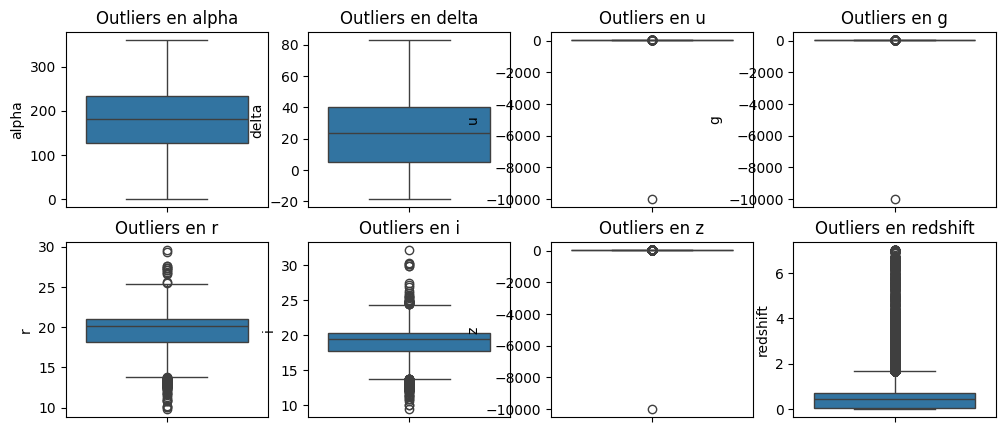

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5))

sns.boxplot(y=df[numerical_cols[0]], ax=axes[0, 0])
axes[0, 0].set_title(f"Outliers en {numerical_cols[0]}")

sns.boxplot(y=df[numerical_cols[1]], ax=axes[0, 1])
axes[0, 1].set_title(f"Outliers en {numerical_cols[1]}")

sns.boxplot(y=df[numerical_cols[2]], ax=axes[0, 2])
axes[0, 2].set_title(f"Outliers en {numerical_cols[2]}")

sns.boxplot(y=df[numerical_cols[3]], ax=axes[0, 3])
axes[0, 3].set_title(f"Outliers en {numerical_cols[3]}")

sns.boxplot(y=df[numerical_cols[4]], ax=axes[1, 0])
axes[1, 0].set_title(f"Outliers en {numerical_cols[4]}")

sns.boxplot(y=df[numerical_cols[5]], ax=axes[1, 1])
axes[1, 1].set_title(f"Outliers en {numerical_cols[5]}")

sns.boxplot(y=df[numerical_cols[6]], ax=axes[1, 2])
axes[1, 2].set_title(f"Outliers en {numerical_cols[6]}")

sns.boxplot(y=df[numerical_cols[7]], ax=axes[1, 3])
axes[1, 3].set_title(f"Outliers en {numerical_cols[7]}")